In [1]:
from shared_2D import *

# Problem setup
- 49 x 50 atoms.
- normalized interatomic-spacing $2^{1/6}$
- outermost 3 layers are atomistic
- no point defects
- initial 5 rep-atoms are handpicked and then kmeans-equilibrated
- boundary conditions 
    - atom at origin is fixed in x and y direction
    - atoms along x-axis are constrained in y
    - atom along y-axis are constrained in x
    - constant horizontal force along right bondary wall 

# Global params 

In [ ]:
# problem specification
NX, NY = 49, 50
LATTICE_SPACING = 2**(1/6)
BORDER_LAYERS = 3
CUTOFF_FACTOR = 1.9 # for 2 nearest-neighbor interaction
PINN_HISTORY_JSON_FILENAME = "pinn-history-2d-neumann/pinn-history-2d-neumann.json"
MAX_ITER = 10000
LOG_EVERY = 100
FORCE_PER_ATOM = np.array([0.1, 0.0])

### helper function for applying constant force on each atom

In [5]:
# apply force-per-atom to atoms on the right boundary wall
# band-width determines how many atoms deep on the right-wall we will apply the force. we want to apply the force on two layers of atoms
def make_force_bc_right_boundary_band(atom_pos,force_per_atom,band_width,tol=1e-12):
    f_ext = np.zeros_like(atom_pos)

    x = atom_pos[:, 0]
    xmax = atom_pos[:, 0].max()

    right_boundary_band = x >= xmax - band_width - tol # atom-positions which have x = [xmax - bandwidth, xmax]

    right_boundary_indices = np.where(right_boundary_band)[0]

    f_ext[right_boundary_band, :] = force_per_atom

    return f_ext, right_boundary_band, right_boundary_indices

## Generate lattice
- split into `continuum` and `atomistic` atoms. Outer 3 layers of atoms are made `atomistic`
- manually pick 5 `rep-atoms` evenly distributed
- equilibrate the `rep-atoms` using `kmeans_unweighted`

In [6]:
atom_pos = make_triangular_lattice(NX,NY,LATTICE_SPACING)

# 3 layers of atoms bordering the square are flagged as atomistic-region
atomistic_indices,continuum_indices = split_atomistic_continuum(NX,NY,BORDER_LAYERS)
continuum_atom_pos = atom_pos[continuum_indices]
atomistic_atom_pos = atom_pos[atomistic_indices]

# manually pick 5 rep_atoms among the continuum atoms 
initial_rep_indices, rep_targets = pick_manual_rep_atoms(atom_pos,continuum_indices,0.1)

# assign continuum-atoms to their clusters, and equilibrate over 100 iterations of kmeans 
cluster_idx, centers, rep_indices, weights, history = kmeans_unweighted(atom_pos,continuum_indices,initial_rep_indices)

print("number of atoms \t\t", len(atom_pos))
print("atomistic atoms \t\t", len(atomistic_indices))
print("continuum atoms \t\t", len(continuum_indices))
print("initial rep atom indices \t", initial_rep_indices)
print("final rep atom indices \t\t", rep_indices)
print("weights \t\t\t", weights)
print("sum of weights \t\t\t", weights.sum())


number of atoms 		 2450
atomistic atoms 		 558
continuum atoms 		 1892
initial rep atom indices 	 [1200  350  384 2065 2099]
final rep atom indices 		 [1200  600  624 1825 1849]
weights 			 [302. 394. 395. 399. 402.]
sum of weights 			 1892.0


## Setup the neighborlist (once)

In [7]:
### Set up the neighbrlist once:
pair_i_np, pair_j_np = build_reference_pair_list(atom_pos, cutoff = CUTOFF_FACTOR*LATTICE_SPACING)
pair_i = torch.tensor(pair_i_np, dtype=TORCH_LONG, device=TORCH_DEVICE)
pair_j = torch.tensor(pair_j_np, dtype=TORCH_LONG, device=TORCH_DEVICE)


## Normalize Inputs
- this is required for PINN input and to generate mask

In [8]:
# normalized inputs
r0,r0_norm = generate_normalized_input(atom_pos=atom_pos)

## Generate mask+offset for Dirichlet BCs
- this is a very specific set of Dirichlet BCs 

In [9]:
# mask for applying dirichlet boundary condition. this is a very specific Dirichlet BC
mask,u_prescribed = generate_dirichlet_mask(r0=r0, atom_pos=atom_pos)

## Setup the 2D PINN with Glorot-Init and Swish-Activation
- 4 hidden layers, 23 neurons per layer
- input layer takes normalized (x,y) coords of each atom
- output layer outputs (ux,uy) displacement vector for each atom
- Swish activation
- Glorot initialization of weights
- The `Glorot` initialization does not influence the final error (error relative to LAMMPS simulation). This was demonstrated by executing multiple training runs and measuring the variance in the error


In [10]:
# initialize the PINN 
model = PINN2D().to(device=TORCH_DEVICE, dtype=TORCH_FLOAT)
adam_opt = torch.optim.Adam(model.parameters(), lr=1e-4) # optimizer adjusts the weights of the NN



## initialize the force-per-atom array

In [11]:
# initialize the force-per-atom 
f_ext_np, right_boundary_band, right_boundary_indices = make_force_bc_right_boundary_band(atom_pos,force_per_atom=FORCE_PER_ATOM,band_width=0.6 * LATTICE_SPACING)
print("number of atoms under force:", np.sum(right_boundary_band))
f_ext = torch.tensor(f_ext_np, dtype=TORCH_FLOAT, device=TORCH_DEVICE)



number of atoms under force: 50


### training routine - this was executed on `HYDRA`
- input normalized-coords into model.
- model predicts new displacement vector field
- apply dirichlet BC to predicted displacement
- evaluate energies of atoms in new positions (`internal-energy`)
- apply neumann BC (`external-work`) to `internal-energy` to get `total-energy`
- do backpropagation on `total-energy` and optimize weights

## Compare `loss-energy` vs `true-energy` (both calculated by PYTHON)
- `loss-energy` is the coarse-grained energy that is used as the objective function in training the PINN
- `true-energy` is the fully atomistic energy of the system.

In [17]:
# read in the PINN output file evaluated from HYDRA
import json
# Load history
with open(PINN_HISTORY_JSON_FILENAME, "r") as jsonfile:
    history = json.load(jsonfile)

# Extract data
epochs = np.array([row["epoch"] for row in history])
loss_energy = np.array([row["loss_energy"] for row in history])
true_energy = np.array([row["true_energy"] for row in history])
pos = np.array([row["pos"] for row in history])

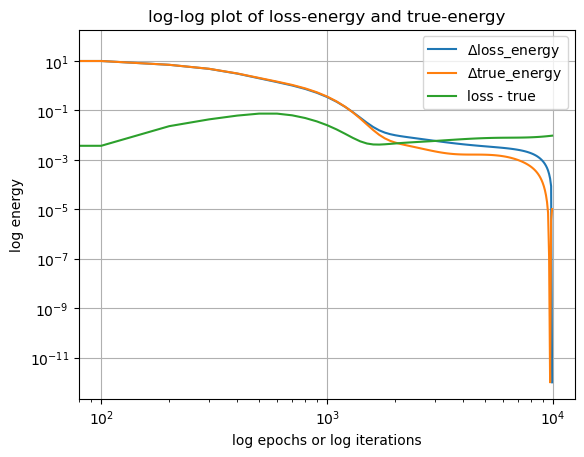

In [18]:
# Plot
plt.figure()
plt.plot(epochs, loss_energy-np.min(loss_energy)+1e-12 ,label='$\\Delta$loss_energy')
plt.plot(epochs, true_energy-np.min(true_energy)+1e-12 ,label='$\\Delta$true_energy')
plt.plot(epochs, np.abs(loss_energy - true_energy),label='loss - true')
plt.xlabel("log epochs or log iterations")
plt.ylabel("log energy")
plt.title("log-log plot of loss-energy and true-energy")
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

# Compare with LAMMPS

In [19]:
from shared_lammps_2D import *

LAMMPS_DIR          =   "./lammps_2d_input_output/"
LAMMPS_TRAJ_FILE    =   LAMMPS_DIR + "relax_2d_neumann_traj.lammpstrj"
LAMMPS_ENERGY_LOG   =   LAMMPS_DIR + "relax_2d_neumann_energy.log"

### Read in the LAMMPS `trajectory` file

In [20]:
timesteps, lammps_frames = read_lammps_trajectory_xy(LAMMPS_TRAJ_FILE)

print(timesteps.shape)
print(lammps_frames.shape)
# shape: (n_frames, n_atoms, 2)

(101,)
(101, 2450, 2)


## Evaluate the `relative-error` in `displacement-vector-field`
$$ \vec{e(t)}_{disp}  = \frac{\lVert \vec{u(t)}_P - \vec{u(t)}_L \rVert}{\lVert \vec{u(t)}_{L} \rVert} $$
- $\vec{u(t)}_P$ is the displacement field predicted by the PINN model at epoch $t$
- $\vec{u(t)}_L$ is the displacement field evaluated by the LAMMPS simulation at iteration $t$

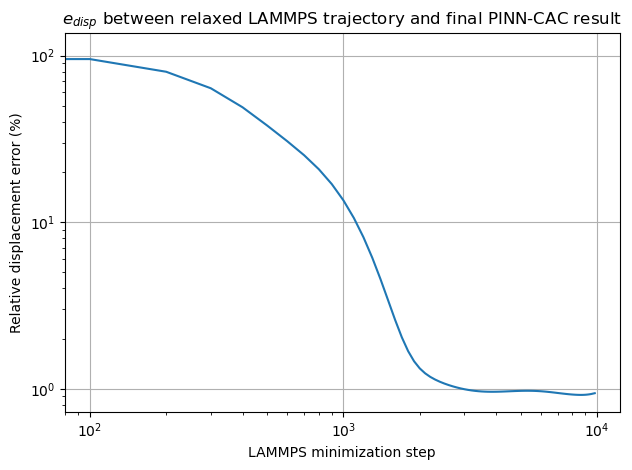

In [21]:
def relative_displacement_error(u_ref, u_pred):
    return np.linalg.norm(u_ref - u_pred) / np.linalg.norm(u_ref)

errors = []

for i in range(1,len(pos)):
    u_lammps = lammps_frames[i] - atom_pos
    u_pinn = pos[i]  - atom_pos
    err = relative_displacement_error(u_lammps,u_pinn)
    errors.append(err)
errors = np.array(errors)

plt.figure()
plt.plot(np.arange(len(errors))*100, 100*errors)
plt.xlabel("LAMMPS minimization step")
plt.ylabel("Relative displacement error (%)")
plt.title("$e_{disp}$ between relaxed LAMMPS trajectory and final PINN-CAC result")
plt.grid(True)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.show()

In [22]:
u_lammps_mags = np.linalg.norm(lammps_frames-atom_pos,axis=2)
u_pinn_mags = np.linalg.norm(pos-atom_pos,axis=2)
relative_err_mags = (np.linalg.norm(lammps_frames[1:]-pos,axis=2)/np.linalg.norm(lammps_frames[1:],axis=2))

/tmp/ipykernel_3682767/2592136731.py:3: RuntimeWarning: invalid value encountered in divide
  relative_err_mags = (np.linalg.norm(lammps_frames[1:]-pos,axis=2)/np.linalg.norm(lammps_frames[1:],axis=2))


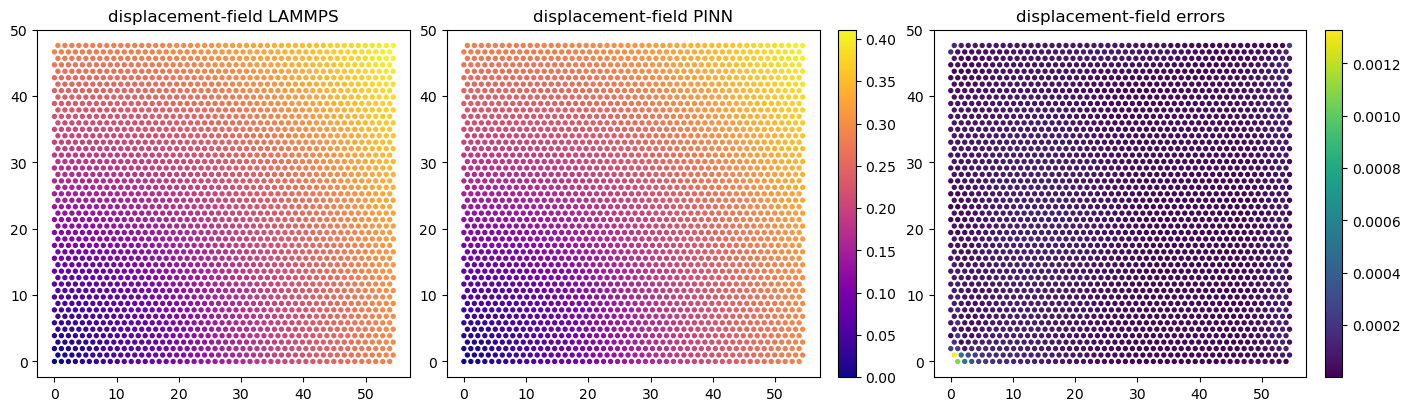

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')

vmin = np.min([np.min(u_pinn_mags[-1]),np.min(u_lammps_mags[-1])])
vmax = np.max([np.max(u_pinn_mags[-1]),np.max(u_lammps_mags[-1])])

scatter_lammps = ax1.scatter(atom_pos[:, 0],atom_pos[:, 1],c=u_lammps_mags[-1],cmap='plasma',s=8,alpha=1,label='LAMMPS',vmin=vmin,vmax=vmax)
scatter_pinn = ax2.scatter(atom_pos[:, 0],atom_pos[:, 1],c=u_pinn_mags[-1],cmap='plasma',s=8,alpha=1,label='PINN',vmin=vmin,vmax=vmax)
cbar_shared = fig.colorbar(scatter_pinn)
ax1.set_title("displacement-field LAMMPS")
ax2.set_title("displacement-field PINN")

scatter_error = ax3.scatter(atom_pos[:, 0],atom_pos[:, 1],c=relative_err_mags[-1],cmap='viridis',s=8,alpha=1,label='error')
cbar_error = fig.colorbar(scatter_error)
ax3.set_title("displacement-field errors")

plt.show()

## Evaluate the `relative-error` in `bond-length-vector`
$$ \vec{err(t)}_{bond}  = \frac{\lVert \vec{b(t)}_P - \vec{b(t)}_L \rVert}{\lVert \vec{b(t)}_{L} \rVert} $$
- bond-length is a vector $\vec{b} = \{b_1, b_2, b_3, ... b_{N_A} \}$ where $b_i$ is the bond-length of atom $i$
- Bond-Length of atom $a$ is given by $\frac{1}{2} \Sigma_{b} \lVert \vec{r_a(t)} - \vec{r_b(t)} \rVert$ where the summation is over all atoms $b$ in the first-nearest-neighbor of atom $a$
- $\vec{b(t)}_P$ is the bond-length vector predicted by the PINN model at epoch $t$
- $\vec{b(t)}_L$ is the bond-length vector evaluated by the LAMMPS simulation at iteration $t$
- NOTE: first-neighbors are evaluated at the referernce configuration (zeroth iteration) 

In [24]:
# find the bond-length-vectors at all times
bond_lengths_lammps = []
bond_lengths_pinn = []
bond_lengths_errors = []
for i in range(len(pos)):
    err_bond, b_lammps, b_pinn = relative_bond_length_error(
        pos0=atom_pos,
        pos_lammps=lammps_frames[i+1],
        pos_pinn=pos[i],
        spacing=2**(1/6),
    )
    bond_lengths_errors.append(err_bond)
    bond_lengths_lammps.append(b_lammps)
    bond_lengths_pinn.append(b_pinn)

bond_lengths_errors = np.array(bond_lengths_errors)
bond_lengths_lammps = np.array(bond_lengths_lammps)
bond_lengths_pinn = np.array(bond_lengths_pinn)

print(f"bond-length error at final iteration/epoch = {100 * bond_lengths_errors[-1]:.6f}%")

bond-length error at final iteration/epoch = 0.022567%


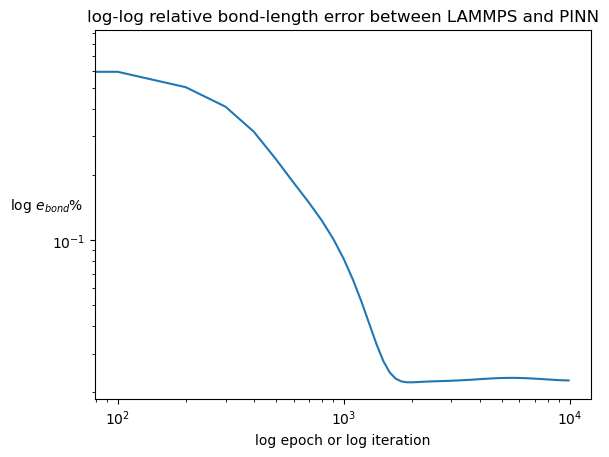

In [25]:
plt.plot(epochs,100*bond_lengths_errors)
plt.yscale('log')
plt.xscale('log')
plt.title('log-log relative bond-length error between LAMMPS and PINN')
plt.xlabel('log epoch or log iteration')
plt.ylabel('log $e_{bond}$%',rotation=0)
plt.show()

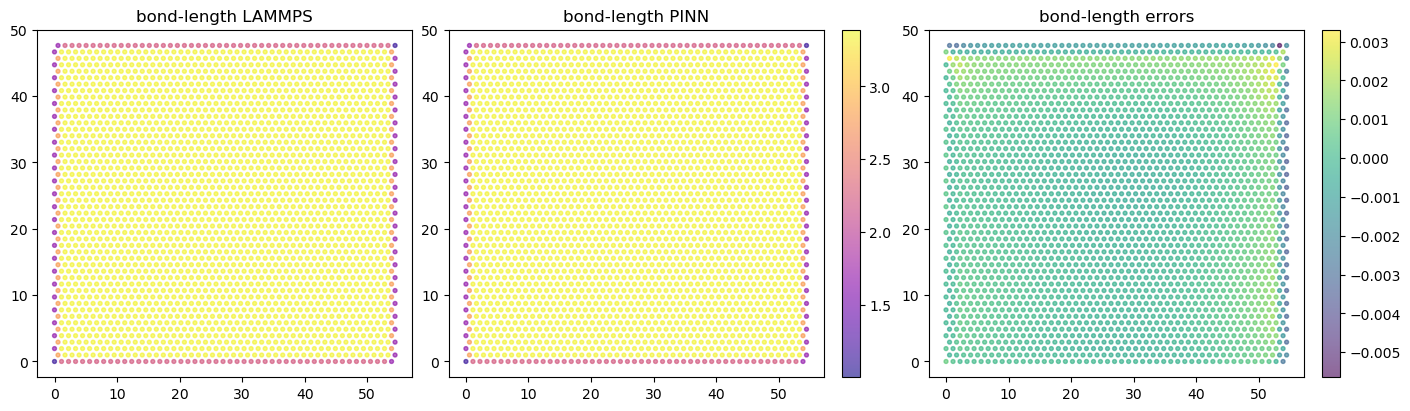

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')
vmin = np.min([np.min(bond_lengths_lammps),np.min(bond_lengths_pinn)])
vmax = np.max([np.max(bond_lengths_lammps),np.max(bond_lengths_pinn)])
scatter_lammps = ax1.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_lammps[-1],cmap='plasma',s=8,alpha=0.6,label='LAMMPS',vmin=vmin,vmax=vmax)
scatter_pinn = ax2.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_pinn[-1],cmap='plasma',s=8,alpha=0.6,label='PINN',vmin=vmin,vmax=vmax)
cbar_shared = fig.colorbar(scatter_pinn)
ax1.set_title("bond-length LAMMPS")
ax2.set_title("bond-length PINN")

scatter_error = ax3.scatter(atom_pos[:, 0],atom_pos[:, 1],c=bond_lengths_pinn[-1]-bond_lengths_lammps[-1],cmap='viridis',s=8,alpha=0.6,label='error')
cbar_error = fig.colorbar(scatter_error)
ax3.set_title("bond-length errors")

plt.show()

## Evaluate the `relative-error` in `total-energy`
$$ err(t)_{E}  = \frac{\lVert E(t)_P - E(t)_L \rVert}{\lVert E(t)_L \rVert} $$
- $E(t)_P$ is the total `coarse-grained-energy` predicted by the PINN model at epoch $t$. 
- $E(t)_L$ is the total `atomistic-energy` evaluated by the LAMMPS simulation at iteration $t$
- The `coarse-grained-energy` is the `loss` function in the PINN. 

### Read in the LAMMPS `energy-logs`

In [27]:
steps, pe, fnorm, fmax = read_lammps_thermo_energy(LAMMPS_ENERGY_LOG)

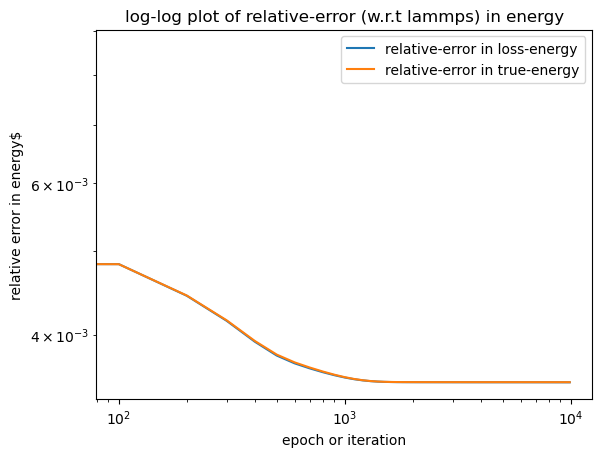

In [28]:
loss_energy_err = np.abs(loss_energy - pe[1:])/np.abs(pe[1:])
true_energy_err = np.abs(true_energy - pe[1:])/np.abs(pe[1:])
plt.plot(epochs,loss_energy_err,label='relative-error in loss-energy')
plt.plot(epochs,true_energy_err,label='relative-error in true-energy')
plt.yscale('log')
plt.xscale('log')
plt.title('log-log plot of relative-error (w.r.t lammps) in energy')
plt.ylabel('relative error in energy$')
plt.xlabel('epoch or iteration')
plt.legend()
plt.show()